# 1.Import Library dan Import Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/adult.csv')

# Memberikan styling ke table

In [2]:
color = ["#0e1647", "#232a62", "#3b4382", "#21A9FF", "#48B7FF", "#6DC6FE", "#9BD9FE", "#C5EBFE"]
df_style = {
    "border" : "1px solid black",
    "border-collapse" : "collapse",
    "font-size" : "14px",
    "background-color" : color[-4],
    "color" : "white"
}

table_style = [
    {"selector": "th", "props": [("border","1px solid black"), ("background-color", color[0]), ("color", "white")]},
    {"selector": "th.col_heading", "props": [("border","1px solid black"), ("background-color", color[0]), ("color", "white")]},
    {"selector": "th.row_heading", "props": [("border","1px solid black"), ("background-color", color[0]), ("color", "white")]},
    {"selector": "tr:nth-child(even) td", "props": [("background-color", color[2])]},
    {"selector": "tr:nth-child(odd) td", "props": [("background-color", color[1])]},
    {"selector": "td", "props": [("border", "1px solid black")]}
]

# 2. Exploratory Data Analaisis

### Identifikasi Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


### Memberikan Styling ke Table dan Menampilkan 10 kolom pertama dari dataset

In [4]:
def target_columns(s, target='income', prev_col='native-country'):
    styles = []
    for col in s.index:
        if col == target:
            styles.append(
                f'background-color: {color[2]} !important; '
                f'border-right: 1px solid gray !important;'
                f'border-left: 1px solid gray !important;'
                f'border-bottom: 1px solid {color[2]} !important;'
                f'border-top: 1px solid {color[2]} !important;'
            )
        elif col == prev_col:
            styles.append(f'border-right: 1px solid gray !important;')
        else:
            styles.append('')
    return styles

def target_header(val, target='income', prev_col='native-country'):
    if val == target:
        return f'background-color: {color[2]} !important; border-right: 1px solid gray !important; border-left: 1px solid gray !important; color: white;'
    elif val == prev_col:
        return f'border-right: 1px solid gray !important;'
    return ''

df.head(10).style.set_properties(**df_style).set_table_styles(table_style).apply(target_columns, axis=1).applymap_index(target_header, axis=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5328\3311169506.py:25: FutureWarning: Styler.applymap_index has been deprecated. Use Styler.map_index instead.
  df.head(10).style.set_properties(**df_style).set_table_styles(table_style).apply(target_columns, axis=1).applymap_index(target_header, axis=1)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


ada data yang tidak dikenali yaitu **(?)** mari kita cek dan tangani setelah ini, dan juga karena kolom **education** dan **educational-num** sama maka saya akan drop yang **educational-num** kenapa? karena jika saya drop kolom **educational-num** nantinya akan mempersulit insight

In [5]:
df = df.drop(columns=['educational-num'])

mantap, sekarang lanjut untuk menangani data **(?)**

In [6]:
df.isin(["?"]).sum().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,0,2799,0,0,0,2809,0,0,0,0,0,0,857,0


terlihat ada banyak data yang tidak dikenali di beberapa kolom yaitu :
- __workclass :__ ada 2795 data yang berisi __(?)__
- __occupation :__ ada 2805 data yang berisi __(?)__
- __native-country :__ ada 856 data yang berisi __(?)__

In [7]:
col_clean = ['workclass', 'occupation', 'native-country']
for col in col_clean:
    df = df[df[col] != "?"]
    
df.isin(["?"]).sum().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


nahh disini sudah beres

### Cek Duplikasi Data

In [8]:
df.duplicated().sum()

np.int64(47)

ada 47 data yang duplikat jika tidak dihapus maka akan mempengaruhi akurasi model, mari kita drop ini

In [9]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


nah sudah berhasil kita hapus

### Cek Kolom yang null/nan

In [10]:
df.isnull().sum().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


terlihat bagus, tidak ada kolom yang null/nan

### Melihat Deskripsi dari kolom number

In [11]:
df.describe().T.style.set_properties(**df_style).set_table_styles(table_style)

,count,mean,std,min,25%,50%,75%,max
age,45175.000000,38.556170,13.215349,17.000000,28.000000,37.000000,47.000000,90.000000
fnlwgt,45175.000000,189738.798450,105652.436515,13492.000000,117392.500000,178312.000000,237903.000000,1490400.000000
capital-gain,45175.000000,1102.576270,7510.249876,0.000000,0.000000,0.000000,0.000000,99999.000000
capital-loss,45175.000000,88.687593,405.156611,0.000000,0.000000,0.000000,0.000000,4356.000000
hours-per-week,45175.000000,40.942512,12.007730,1.000000,40.000000,40.000000,45.000000,99.000000


__Cara membaca deskripsi number :__ <br>
1. count adalah total sampel pada kolom tersebut
2. mean adalah nilai rata-ratanya
3. std adalah standard deviation digunakan untuk mengukur rentan nilai dari rata-rata
4. min nilai terkecil
5. 25% adalah quartil 1
6. 25% adalah quartil 2
7. 25% adalah quartil 3
8. max adalah nilai tertinggi

dari dataset diatas bisa di simpulkan kalau seperti nya ada outlier di column **capital-loss** dan **capital-gain**, namun saya akan mengatasi outlier ini setelah insight bisa kita drop atau kita atasi outlier nya tergantung dari insight yang kita dapat nanti

### Melihat Deskripsi dari kolom Kategorikal

In [12]:
df.describe(include='object').T.style.set_properties(**df_style).set_table_styles(table_style)

,count,unique,top,freq
workclass,45175,7,Private,33262
education,45175,16,HS-grad,14770
marital-status,45175,7,Married-civ-spouse,21042
occupation,45175,14,Craft-repair,6010
relationship,45175,6,Husband,18653
race,45175,5,White,38859
gender,45175,2,Male,30495
native-country,45175,41,United-States,41256
income,45175,2,<=50K,33973


__Cara membaca deskripsi number__:<br>
1. count adalah total sampel pada kolom tersebut
2. unique adlaah jumlah berapa banyak data yang unik
3. top adalah nilai yang sering muncul / modus
4. freq adalah frekuensi berapa kali nilai top sering muncul

### Splitting data numerical dan kategorikal

In [13]:
num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols = df.select_dtypes(include='object').columns.to_list()

In [14]:
for col in cat_cols:
    print(f"{col} : {df[col].unique()}")

workclass : ['Private' 'Local-gov' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay']
education : ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' '5th-6th' 'Assoc-voc' '9th' 'Doctorate'
 '12th' '1st-4th' 'Preschool']
marital-status : ['Never-married' 'Married-civ-spouse' 'Widowed' 'Separated' 'Divorced'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation : ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' 'Other-service'
 'Prof-specialty' 'Craft-repair' 'Adm-clerical' 'Exec-managerial'
 'Tech-support' 'Sales' 'Priv-house-serv' 'Transport-moving'
 'Handlers-cleaners' 'Armed-Forces']
relationship : ['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']
race : ['Black' 'White' 'Other' 'Amer-Indian-Eskimo' 'Asian-Pac-Islander']
gender : ['Male' 'Female']
native-country : ['United-States' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany' 'Philippines' 'Thailand' 

### Binning untuk memudahkan 

In [15]:
workclass_binning = {
    'Private': 'Private',
    'Self-emp-not-inc': 'Self-Employed',
    'Self-emp-inc': 'Self-Employed',
    'Federal-gov': 'Government',
    'State-gov': 'Government',
    'Local-gov': 'Government',
    'Without-pay': 'Unpaid'
}

df['workclass'] = df['workclass'].map(workclass_binning)

def bin_education(x):
    if x in ['Preschool', '1st-4th', '5th-6th', '7th-8th']:
        return 'Elementary'
    elif x in ['9th', '10th', '11th', '12th']:
        return 'High School (Non-grad)'
    elif x == 'HS-grad':
        return 'High School Grad'
    elif x == 'Some-college':
        return 'Some College'
    elif x in ['Assoc-acdm', 'Assoc-voc']:
        return 'Associate'
    elif x == 'Bachelors':
        return 'Bachelor'
    elif x in ['Masters', 'Doctorate', 'Prof-school']:
        return 'Postgrad'
    else:
        return 'Other'
df['education'] = df['education'].apply(bin_education)

def bin_marital(x):
    if x == 'Never-married':
        return 'Single'
    elif x in ['Married-civ-spouse', 'Married-AF-spouse']:
        return 'Married'
    elif x in ['Divorced', 'Separated']:
        return 'Separated/Divorced'
    elif x == 'Widowed':
        return 'Widowed'
    else:
        return 'Other'
df['marital-status'] = df['marital-status'].apply(bin_marital)

def bin_occupation(x):
    if x in ['Exec-managerial', 'Prof-specialty']:
        return 'Professional'
    elif x in ['Craft-repair', 'Machine-op-inspct', 'Transport-moving', 'Handlers-cleaners']:
        return 'Skilled Labor'
    elif x in ['Adm-clerical', 'Sales', 'Tech-support']:
        return 'Clerical/Support'
    elif x in ['Other-service', 'Priv-house-serv', 'Protective-serv']:
        return 'Service'
    elif x == 'Farming-fishing':
        return 'Agriculture'
    elif x == 'Armed-Forces':
        return 'Military'
    else:
        return 'Other'
df['occupation'] = df['occupation'].apply(bin_occupation)


mari kita cek nilai nya setelajh kita binning

In [16]:
cat_cols = df.select_dtypes(include='object').columns.to_list()
for col in cat_cols:
    print(f'{col} : {df[col].unique()}')

workclass : ['Private' 'Government' 'Self-Employed' 'Unpaid']
education : ['High School (Non-grad)' 'High School Grad' 'Associate' 'Some College'
 'Postgrad' 'Elementary' 'Bachelor']
marital-status : ['Single' 'Married' 'Widowed' 'Separated/Divorced' 'Other']
occupation : ['Skilled Labor' 'Agriculture' 'Service' 'Professional' 'Clerical/Support'
 'Military']
relationship : ['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']
race : ['Black' 'White' 'Other' 'Amer-Indian-Eskimo' 'Asian-Pac-Islander']
gender : ['Male' 'Female']
native-country : ['United-States' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany' 'Philippines' 'Thailand' 'Haiti' 'El-Salvador'
 'Puerto-Rico' 'Vietnam' 'South' 'Columbia' 'Japan' 'India' 'Cambodia'
 'Poland' 'Laos' 'England' 'Cuba' 'Taiwan' 'Italy' 'Canada' 'Portugal'
 'China' 'Nicaragua' 'Honduras' 'Iran' 'Scotland' 'Jamaica' 'Ecuador'
 'Yugoslavia' 'Hungary' 'Hong' 'Greece' 'Trinadad&Tobago'
 'Outlying-US(Guam-USVI-e

maka akan terlihat lebih rapi dan gampang di baca

# 3. Analisis Trend

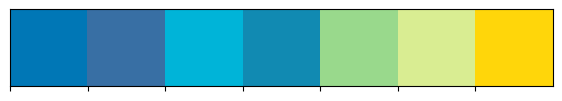

In [17]:
color_variance = ["#0077b6", "#386fa4", "#00b4d8", "#118ab2", "#99d98c", "#d9ed92", "#ffd60a"]

sns.palplot(sns.color_palette(color_variance))

### Melihat Distribusi Income

C:\Users\Admin\AppData\Local\Temp\ipykernel_5328\1236056296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='income', palette=[color_variance[0], color_variance[6]])


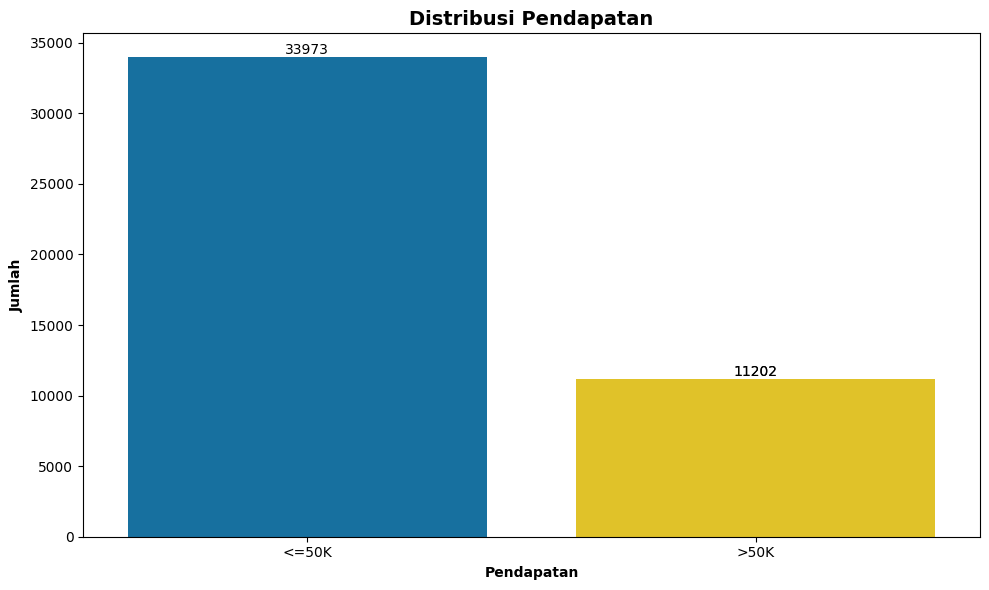

In [18]:
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(data=df, x='income', palette=[color_variance[0], color_variance[6]])
plt.title("Distribusi Pendapatan", fontsize=14, fontweight='bold')
plt.xlabel('Pendapatan', fontweight='bold')
plt.ylabel('Jumlah', fontweight='bold')
for container in ax.containers:
    ax.bar_label(container)
ax.bar_label(ax.containers[1])
plt.tight_layout()
plt.show()

Mayoritas individu dalam dataset ini berpenghasilan kurang dari atau sama dengan 50K per tahun, Hanya sebagian kecil yang memiliki pendapatan lebih dari 50K, data ini terlihat imbalance nanti akan kita sampler saat di preprocessing

### Melihat Distribusi Capital Gain & Capital Loss

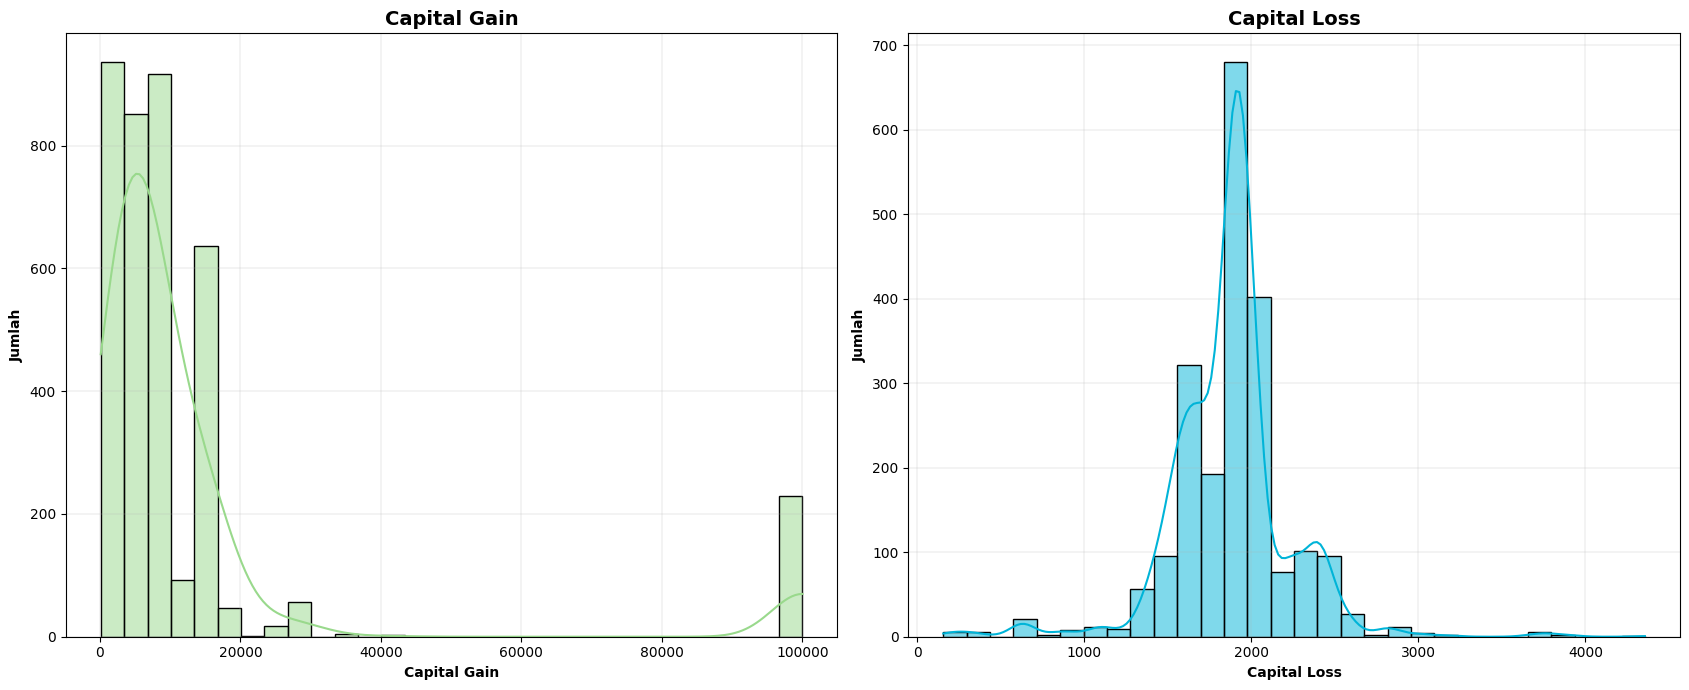

In [19]:
columns = ['capital-gain', 'capital-loss']
palette = [color_variance[4], color_variance[2]]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for i, col in enumerate(columns):
    data = df[df[col] > 0][col]
    sns.histplot(data=data, kde=True, bins=30, ax=axes[i], color=palette[i])
    axes[i].set_title(f'{col.replace("-", " ").title()}', fontweight='bold', fontsize=14)
    axes[i].set_xlabel(col.replace("-", " ").title(), fontweight='bold',)
    axes[i].set_ylabel('Jumlah', fontweight='bold',)
    axes[i].grid(True, linewidth=0.2)

plt.tight_layout()
plt.show()

__Hasil Analisis__
- Mayoritas orang tidak memiliki capital gain/loss, tapi sebagian kecil memiliki nilai gain/loss besar, yang bisa jadi indikator investasi atau bisnis. Distribusinya sangat skewed hanya beberapa yang mendapatkan nilai tinggi.

### Melihat Distribusi Umur dan Waktu Bekerja

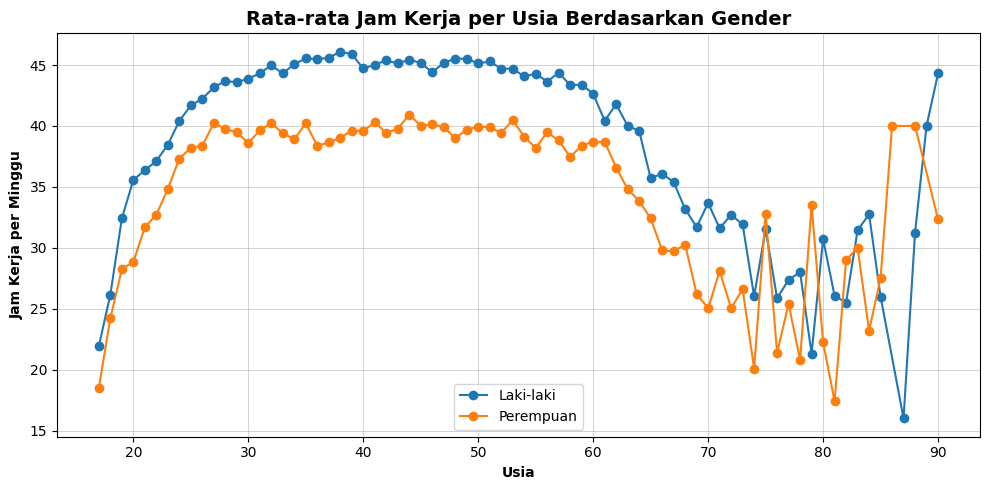

In [20]:
male = df[df['gender'] == 'Male']
female = df[df['gender'] == 'Female']

male_trend = male.groupby('age')['hours-per-week'].mean()
female_trend = female.groupby('age')['hours-per-week'].mean()

plt.figure(figsize=(10, 5))
plt.title("Rata-rata Jam Kerja per Usia Berdasarkan Gender", fontweight='bold', fontsize=14)
plt.plot(male_trend.index, male_trend.values, marker='o', label='Laki-laki')
plt.plot(female_trend.index, female_trend.values, marker='o', label='Perempuan')
plt.xlabel("Usia", fontweight='bold')
plt.ylabel("Jam Kerja per Minggu", fontweight='bold')
plt.legend(loc='lower center')
plt.grid(True, linewidth=0.4)
plt.tight_layout()
plt.show()

__Hasil Analisis__
- Baik Laki-laki maupun Perempuan mengalami peningkatan jam kerja dari usia remaja hingga usia 30 tahun an
- setelah usia 60 tahun, jam kerja menurun drastis, kemungkinan karna banyak yang sudah pensiun
- Laki-laki secara konsisten memiliki jam kerja lebih tinggi dibanding perempuan, terutama di usia produktif (sekitar 25–60 tahun).

### Mengecek apakah ada kesenjangan sosial

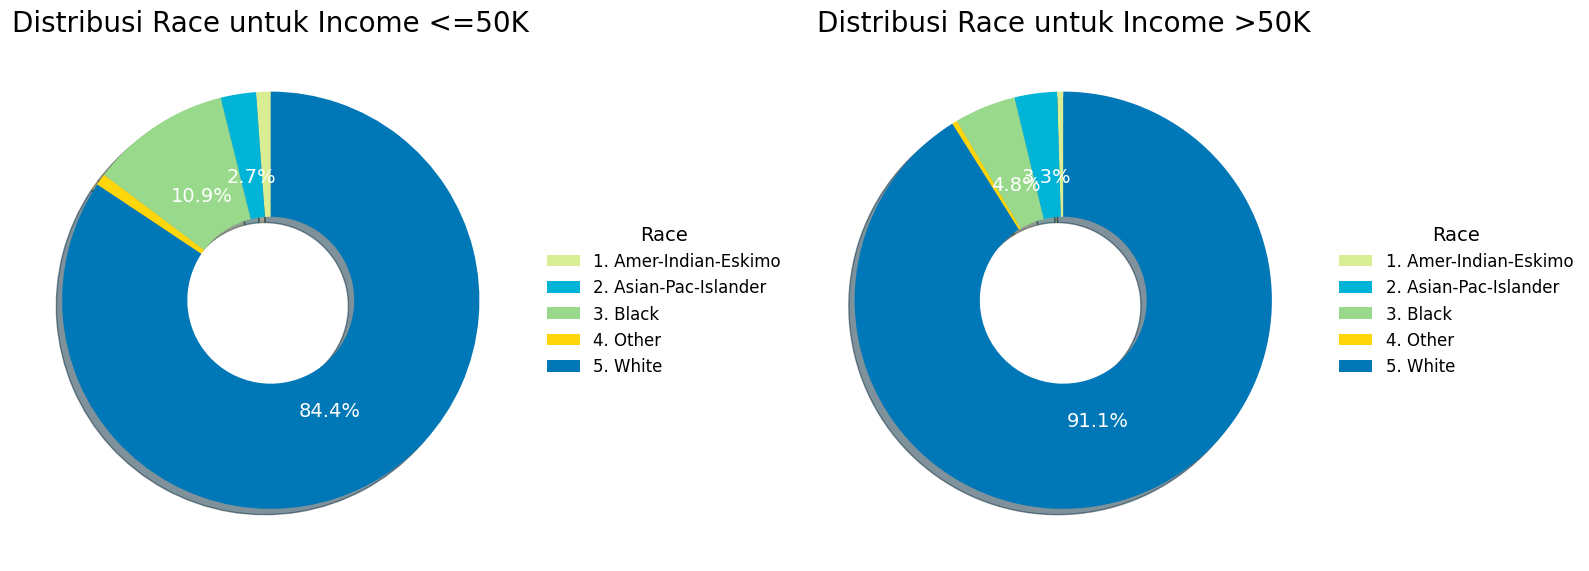

In [21]:
grouped = df.groupby(['income', "race"]).size().unstack(fill_value=0)
donut_color = [color_variance[5], color_variance[2], color_variance[4], color_variance[6], color_variance[0]]
fig, ax = plt.subplots(1, 2, figsize=(16, 10))

for i, income in enumerate(grouped.index):
    data = grouped.loc[income]
    wedges, texts, autotexts = ax[i].pie(
        data,
        autopct=lambda pct:('%1.1f%%' % pct) if pct > 2 else '',
        startangle=90,
        shadow=True,
        # explode=(0.035,0.1,0.035,0.035,0.1),
        wedgeprops=dict(width=0.6),
        colors=donut_color,
    )
    ax[i].set_title(f'Distribusi Race untuk Income {income}', size=20)

    for autotext in autotexts:
      autotext.set_color("white")
      autotext.set_fontsize(14)

      ax[i].legend(
        wedges,
        [f"{i+1}. {label}" for i, label in enumerate(data.index)],
        title="Race",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False,
        title_fontsize=14,
        fontsize=12
      )

plt.tight_layout()
plt.show()

__Hasil Analisis__<br>
Ada kecenderungan bahwa kelompok ras "White" memiliki peluang lebih tinggi berada di kategori penghasilan >50K, sementara ras lainnya lebih dominan di kelompok <=50K. Ini bisa jadi indikasi adanya disparitas sosial ekonomi berdasarkan ras dalam dataset ini.

1. __Ras "White" mendominasi kedua kelompok penghasilan baik rendah maupun tinggi.__ dan jumlahnya bahkan lebih besar pada kelompok penghasilan tinggi<br>

2. __Ras "Black" memiliki representasi yang jauh lebih besar di kelompok <=50K dibandingkan >50K,__ menunjukkan potensi adanya kesenjangan ekonomi berdasarkan ras.<br>

3. Ras-ras minoritas seperti __Asian-Pac-Islander, Amer-Indian-Eskimo, dan Other__ memiliki porsi sangat kecil di kedua kelompok penghasilan, dan semakin kecil di kelompok >50K.

In [22]:
df = df.drop(columns=['race'])
# drop kolom race karena datanya redudnan dan berpotensi overfitting

### Melihat Jumlah Workclass berdasarkan Income

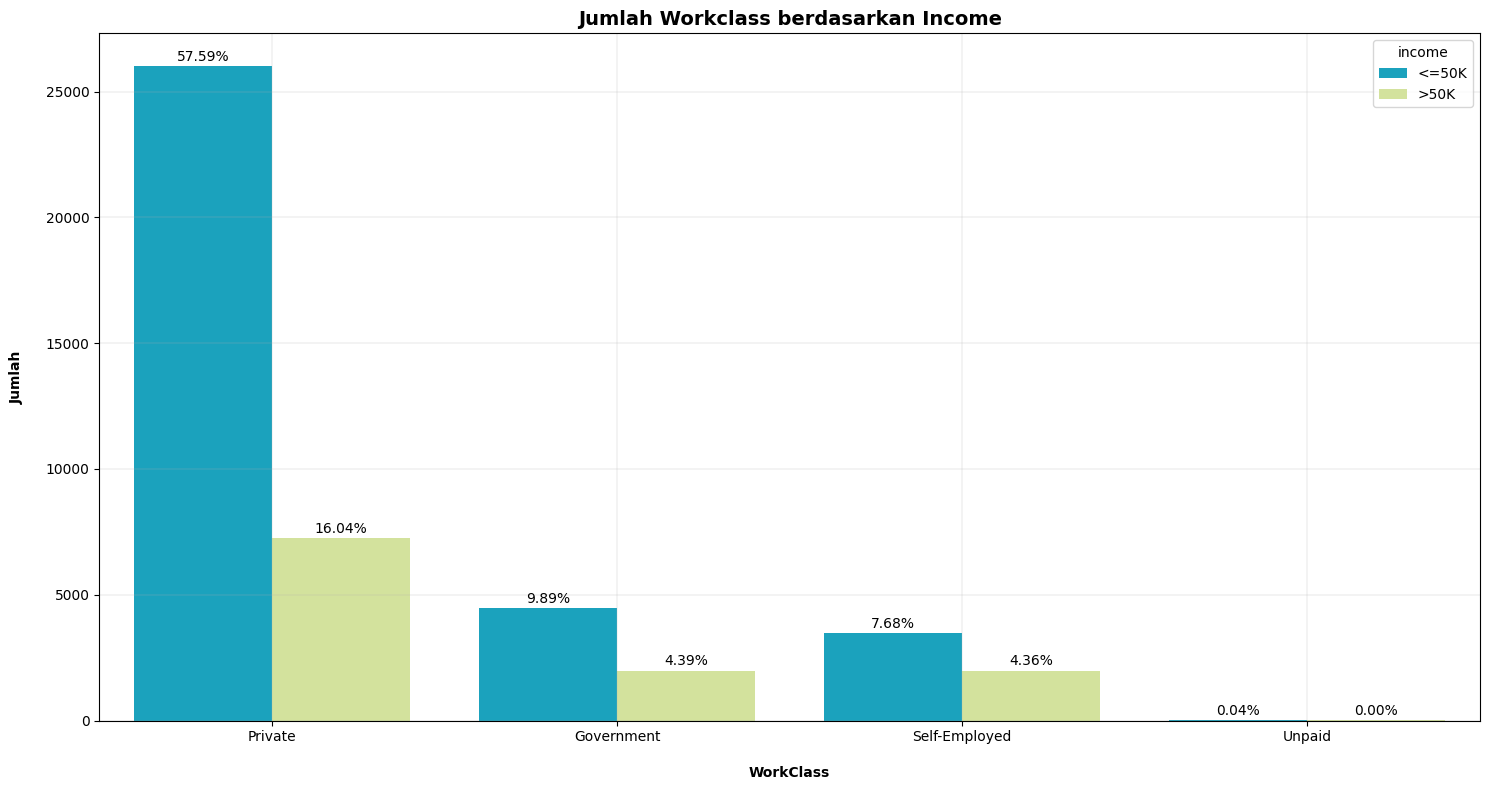

In [23]:
work_income_counts = df.groupby(['workclass', 'income']).size().reset_index(name='count')
work_values = df['workclass'].value_counts()
fig, ax = plt.subplots(figsize=(15,8))
sns.countplot(
    data=df,
    x='workclass', 
    order=work_values.index,
    palette=[color_variance[2],
             color_variance[5]],
    hue='income',
    ax=ax)
plt.title('Jumlah Workclass berdasarkan Income', fontweight='bold', fontsize=14)
plt.xlabel('\nWorkClass', fontweight='bold')
plt.ylabel('Jumlah\n', fontweight='bold')
plt.tick_params(axis='x')

total = len(df)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height + 100,
                    f'{(height/total)*100:.2f}%',
                    ha='center', va='bottom')
plt.tight_layout()
plt.grid(linewidth=0.2)
plt.show()

__Hasil Analisis__
- Mayoritas bekerja di sektor Private, workclass Private adalah jumlah terbanyak, terutama untuk pendapatan <=50K (57.59% dari total populasi).
- Hanya 16.04% dari sektor Private yang berpenghasilan >50K, menunjukkan bahwa mayoritas pekerja di workclass swasta memiliki pendapatan di bawah 50K.
- Grafik ini bisa mengindikasikan bahwa pekerjaan di workclass non-swasta berpeluang lebih besar untuk mendapatkan penghasilan >50K, meskipun secara total jumlah pekerjanya lebih sedikit.

### Melihat Rata Rata Pendidikan berdasarkan Income

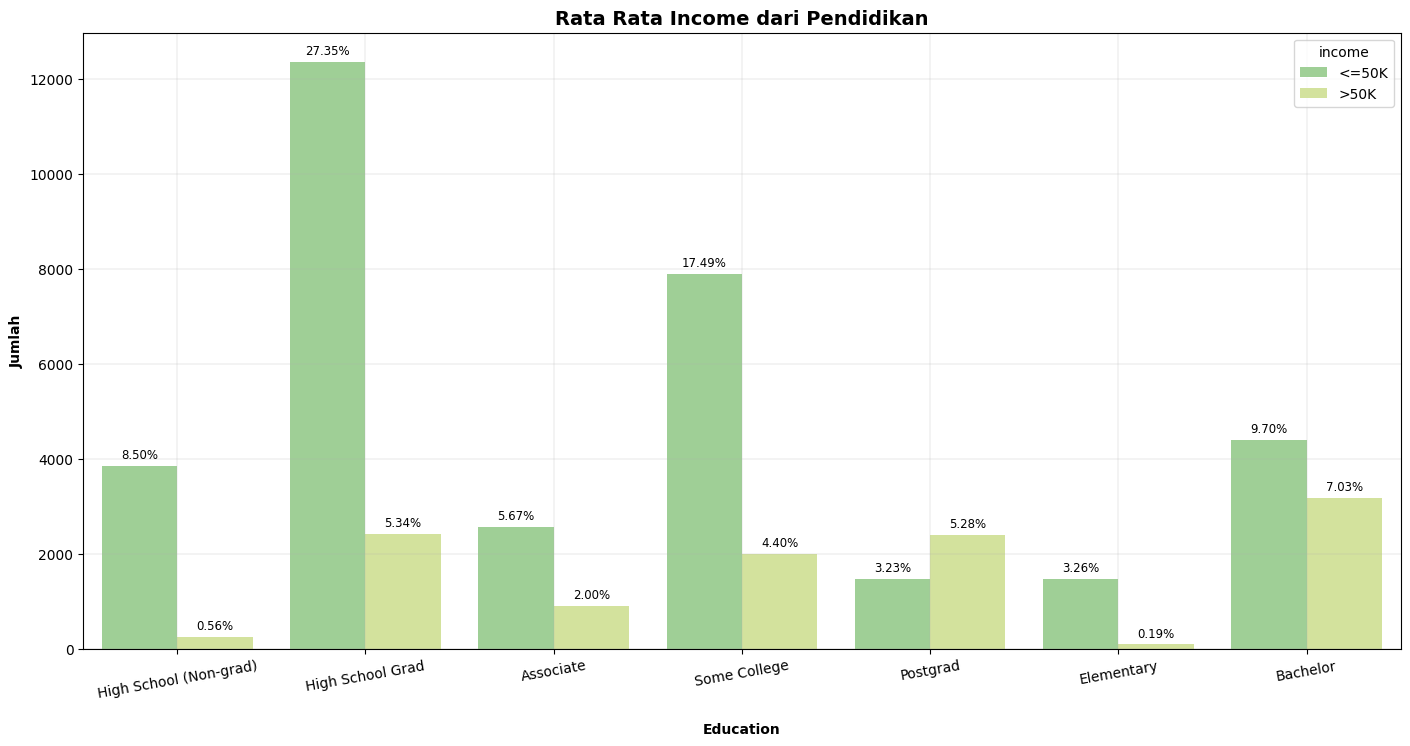

In [24]:
fig, ax = plt.subplots(figsize=(17,8))
sns.countplot(x='education',data=df, palette=[color_variance[4], color_variance[5]], hue='income')
plt.title('Rata Rata Income dari Pendidikan', fontweight='bold', fontsize=14)
plt.xlabel('\nEducation', fontweight='bold')
plt.ylabel('Jumlah', fontweight='bold')
plt.tick_params(axis='x', rotation=10)
total = len(df)
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() /2,
                    height + 100,
                    f'{(height/total)*100:.2f}%',
                    ha='center', va='bottom', fontsize=8.5)
plt.grid(linewidth=0.2)
plt.show()

__Hasil Analisis__
- Semakin tinggi pendidikan, semakin besar peluang menghasilkan >50K.
- Pendidikan memiliki peran signifikan dalam mobilitas ekonomi dan potensi penghasilan.

# 3. Data Preprocessing

### Cek Outlier pada kolom Numeris

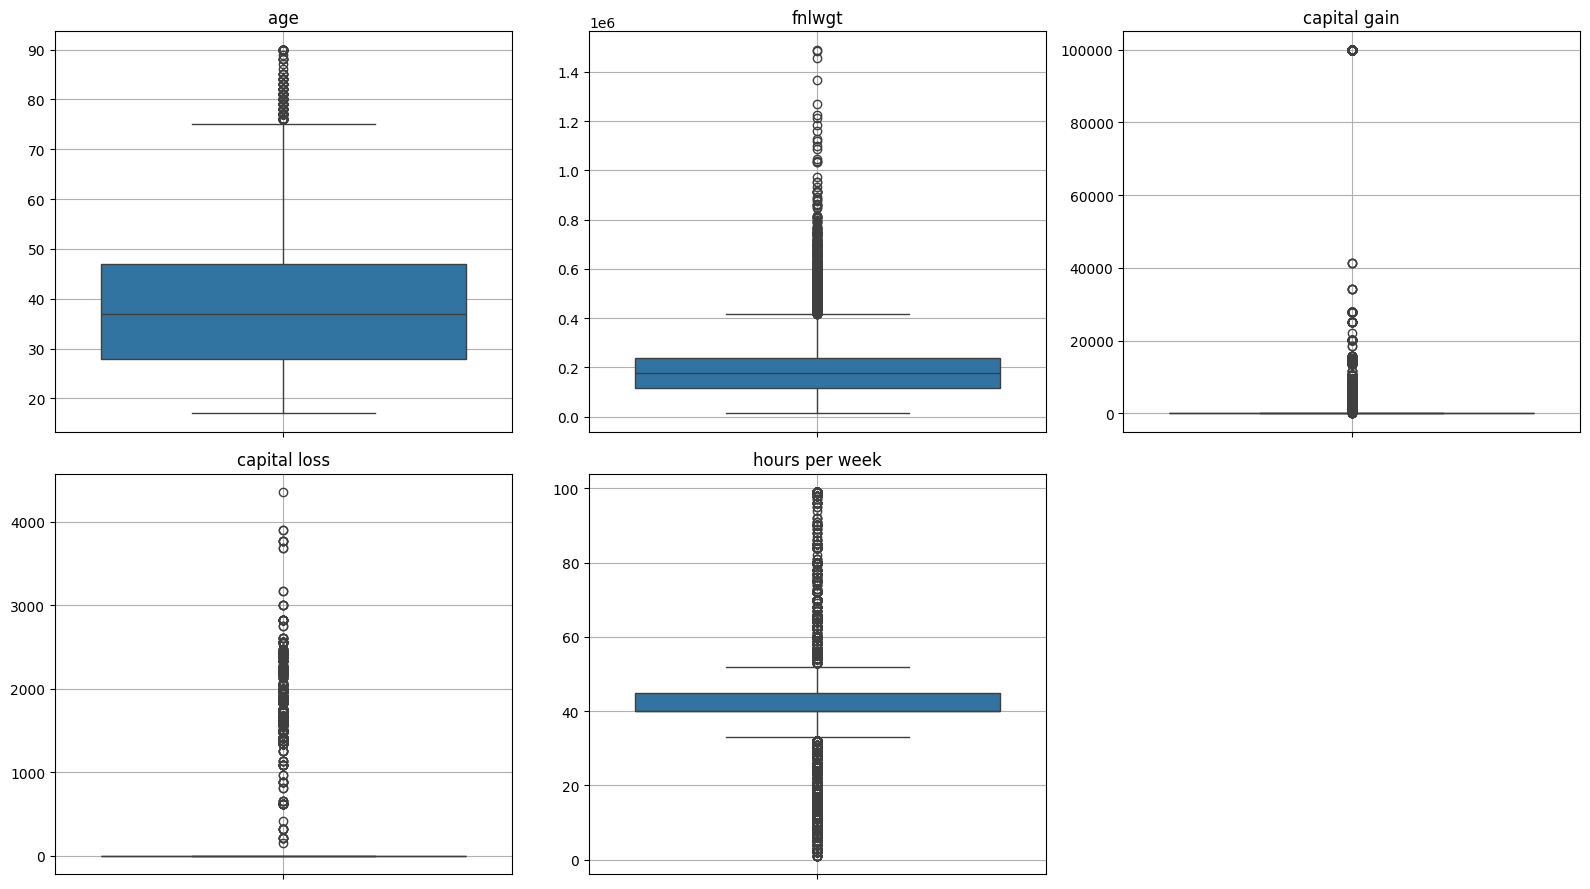

In [25]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 8, n_cols * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col]
    
    axes[i].set_title(col.replace("-", " "))
    sns.boxplot(y=data, ax=axes[i])
    axes[i].set_ylabel(None)
    axes[i].grid(True)
    
for j in range(len(num_cols), n_rows * n_cols):
    plt.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

##### Menangani Outlier

In [26]:
len(df[df['capital-gain'] > 80000])

229

In [27]:
df_gain_clear = df[df['capital-gain'] < 80000]

In [28]:
kolom = ['age', 'fnlwgt', 'hours-per-week']
for col in kolom:
    Q1 = df_gain_clear[col].quantile(0.25)
    Q3 = df_gain_clear[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean_outlier = df_gain_clear[(df_gain_clear[col] >= lower) & (df_gain_clear[col] <= upper)]

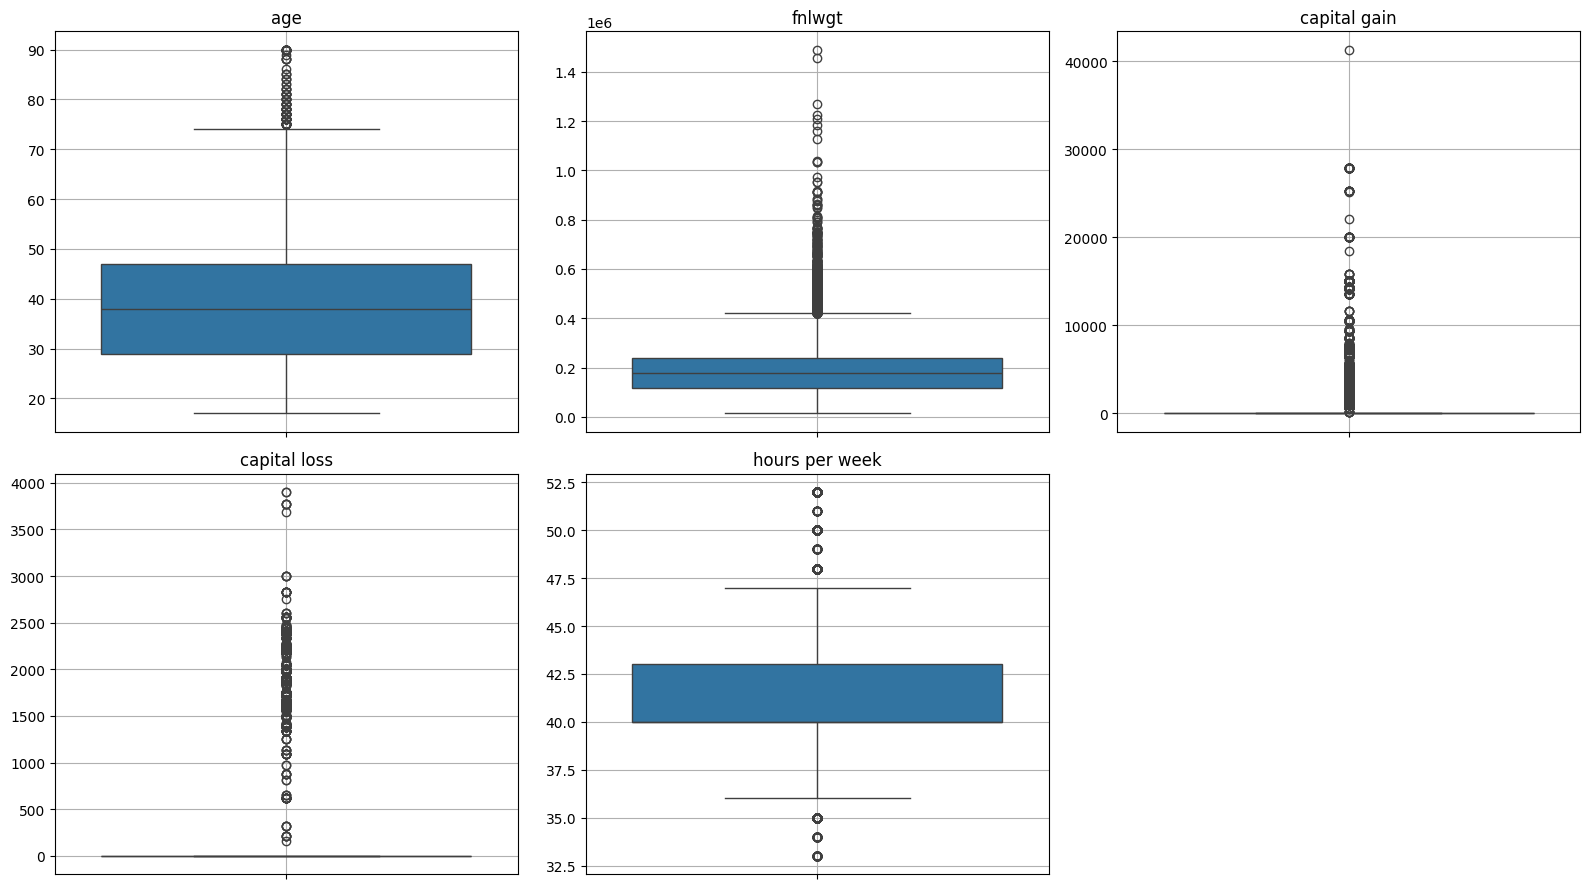

In [29]:
num_cols = df_clean_outlier.select_dtypes(include='number').columns.to_list()
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 8, n_cols * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_clean_outlier[col]
    
    axes[i].set_title(col.replace("-", " "))
    sns.boxplot(y=data, ax=axes[i])
    axes[i].set_ylabel(None)
    axes[i].grid(True)
    
for j in range(len(num_cols), n_rows * n_cols):
    plt.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

maka akan seperti ini ini terlihat seperti masih ada outlier tetapi ini adalah data real 

## Cek imbalance data

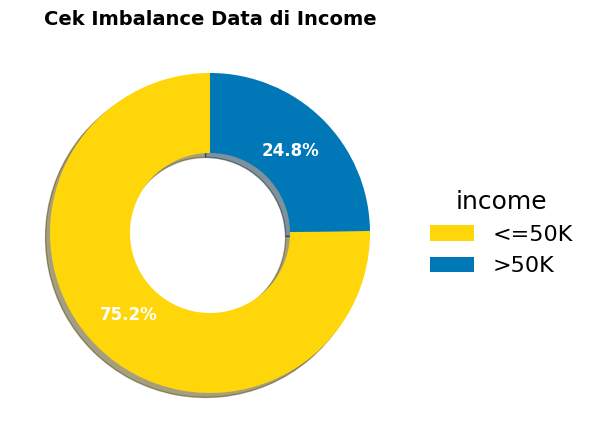

In [30]:
col = "income"
color = [color_variance[6], color_variance[0]]
data = df[col].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

wedges, text, autotexts = ax.pie(
    x=data,
    colors=color,
    startangle=90,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.5),
    shadow=True,
    pctdistance=0.72
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")
    
ax.legend(
    wedges,
    data.index,
    title=col,
      loc="center left",
      bbox_to_anchor=(1, 0.5),
      frameon=False,
      title_fontsize=18,
      fontsize=16,
)
    
plt.title('Cek Imbalance Data di Income', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

data target disini terlihat imbalance maka langkah yang tepat adalah kita resampling, kenapa? karena model knn sangat sensitif terhadap data yang tidak seimbang atau imbalance maka kita harus lakukan resampling, tujuan resampling adalah untuk mengubah data tiap kelas agar lebih seimbang

In [31]:
def oversampling(X, y):
  df = pd.DataFrame(X)
  name = y.to_frame().columns[0]
  df[name] = y
  
  classes = df[name].unique()
#   max_count = df[name].value_counts().max()
  min_count = df[name].value_counts().min() # under sampler
  
  df_balanced = pd.concat([
    df[df[name] == c].sample(min_count, replace=True, random_state=42)
    for c in classes
  ])
  
  return df_balanced

In [32]:
df_balanced = oversampling(df_clean_outlier.drop(columns=['income']),df.income)


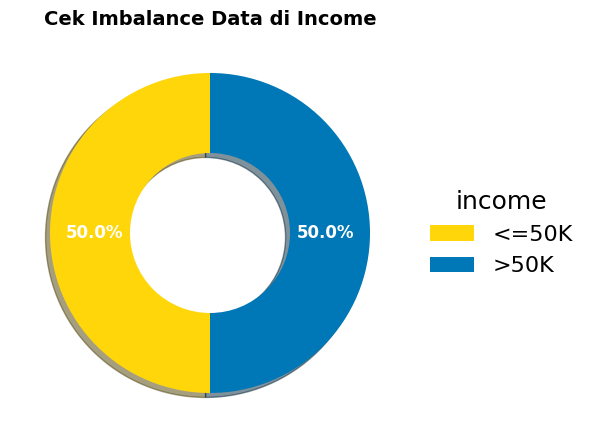

In [33]:
col = "income"
color = [color_variance[6], color_variance[0]]
data = df_balanced[col].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))

wedges, text, autotexts = ax.pie(
    x=data,
    colors=color,
    startangle=90,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.5),
    shadow=True,
    pctdistance=0.72
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")
    
ax.legend(
    wedges,
    data.index,
    title=col,
      loc="center left",
      bbox_to_anchor=(1, 0.5),
      frameon=False,
      title_fontsize=18,
      fontsize=16,
)
    
plt.title('Cek Imbalance Data di Income', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Feature Selection

encode kolom kategorical

In [34]:
def label_encoder(df: pd.DataFrame):
  unq_map = dict()
  for col in cat_cols:
    if col in df.columns:
      unq = df[col].unique()
      unq_map[col] = {v: k for k, v in enumerate(unq)}
      df[col] = df[col].map(unq_map[col])
    
  return df, unq_map

In [35]:
df_encoded, struct = label_encoder(df_balanced)
df_encoded.head().style.set_properties(**df_style).set_table_styles(table_style)

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,native-country,income
46801,21,0,502837,0,0,0,0,0,0,0,40,0,0
31312,49,1,223342,1,1,1,1,0,0,0,44,1,0
1694,40,0,119008,0,1,2,2,0,0,0,40,1,0
10586,45,1,199925,2,0,1,2,1,0,0,48,1,0
42717,32,0,227931,3,0,3,1,0,0,0,40,1,0


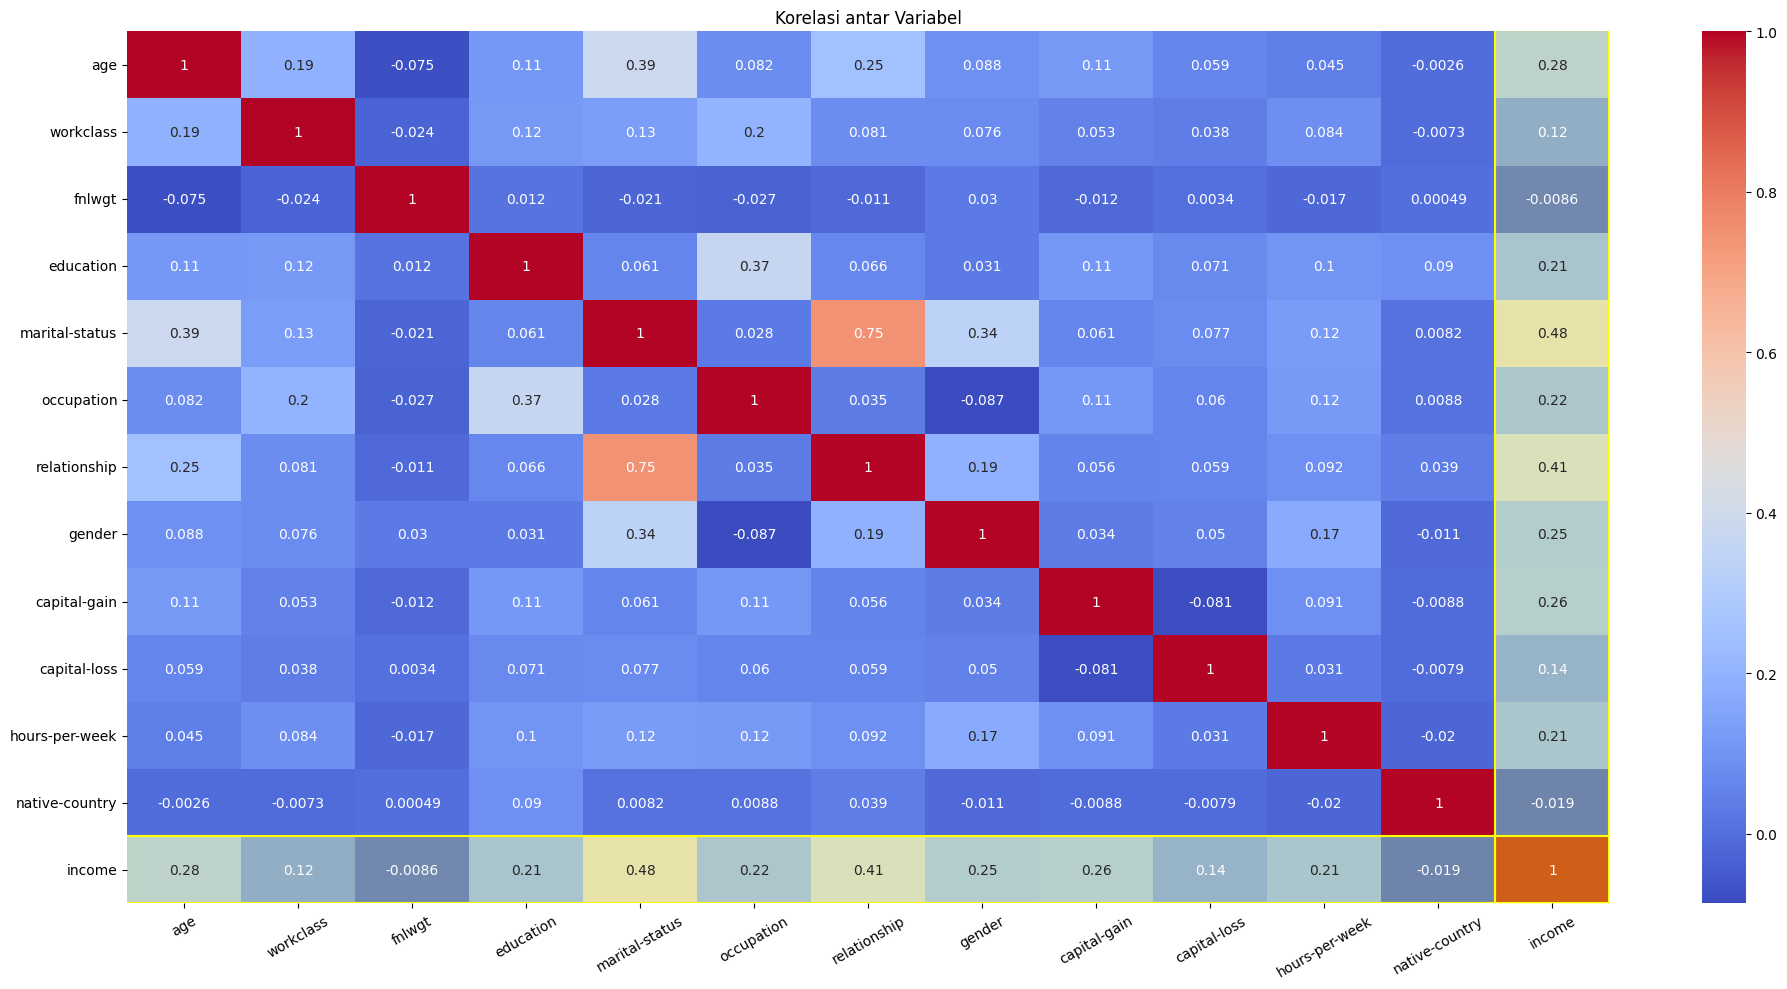

In [36]:
plt.figure(figsize=(20, 10))
plt.title('Korelasi antar Variabel')

corr = df_encoded.corr()
idx = list(corr.columns).index("income")

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.axvline(idx, color='yellow', linewidth=1.5)
plt.axvline(idx + 1, color='yellow', linewidth=1.5)
plt.fill_betweenx(y=[0, corr.shape[0]], x1=idx, x2=idx + 1, color='yellow', alpha=0.2)

plt.axhline(idx, color='yellow', linewidth=1.5)
plt.axhline(idx + 1, color='yellow', linewidth=1.5)
plt.fill_between(x=[0, df.shape[0]], y1=idx, y2=idx + 1, color='yellow', alpha=0.2)   

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Hasil Korelasi dari kolom diatas menunjukan bahwa ada beberapa feature yang ber korelasi tinggi yaitu fitur :<br>
[ **martial-status, relationship, age, education, occupation, gender, capital-gain, hours-per-week** ] <br>
mari kita lihat lagi menggunakan teknik lain

#### Feature Selection Menggunakan MI ( Mutual Information )

In [37]:
def mutual_information(x, y, bins=10):
    # Diskretisasi jika data numerik
    x = np.digitize(x, bins=np.histogram_bin_edges(x, bins=bins))
    y = np.digitize(y, bins=np.histogram_bin_edges(y, bins=bins))

    N = len(x)
    mi = 0

    x_values = np.unique(x)
    y_values = np.unique(y)

    for xi in x_values:
        for yi in y_values:
            p_xy = np.sum((x == xi) & (y == yi)) / N
            if p_xy == 0:
                continue
            p_x = np.sum(x == xi) / N
            p_y = np.sum(y == yi) / N
            mi += p_xy * np.log2(p_xy / (p_x * p_y))
    
    return mi

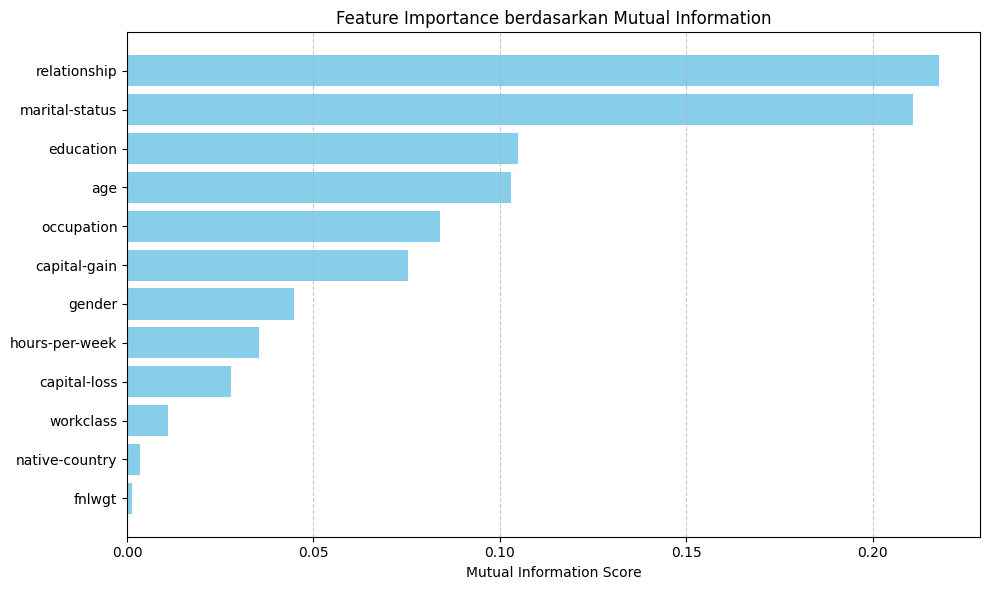

In [38]:
X = df_encoded.drop(columns='income')
y = df_encoded['income']

mi_scores = {col: mutual_information(X[col], y) for col in X.columns}

sorted_mi = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)
features = [k for k, _ in sorted_mi]
scores = [v for _, v in sorted_mi]

plt.figure(figsize=(10, 6))
bars = plt.barh(features[::-1], scores[::-1], color='skyblue')
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance berdasarkan Mutual Information")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Hasil dari Mutual Information diatas adalah saya akan mengambil feature : <br>
[ **relation-ship, martial-status, education, age, occupation, capital-gain** ] <br>
tersisa kolom : [ __gender, hours-per-week, capital-loss, workclass, native-country, fnlwgt__ ] <br>

setelah saya pertimbangkan saya akan mengambil juga kolom **capital-loss** karena saya mengambil kolom **capital-gain** Jika hanya mempertimbangkan keuntungan modal (capital-gain) tanpa mempertimbangkan kemungkinan adanya kerugian modal (capital-loss), maka informasi yang diperoleh akan tidak seimbang <br>

lalu saya juga akan mengambil kolom **hours-per-week** karena kolom ini menampilkan informasi jam kerja per minggu Semakin banyak seseorang bekerja dalam seminggu, semakin besar kemungkinan ia mendapatkan penghasilan yang lebih tinggi.

In [39]:
df_feature_select = df_encoded.drop(columns=['gender', 'workclass', 'native-country', 'fnlwgt'])
df_feature_select.head().style.set_properties(**df_style).set_table_styles(table_style)


,age,education,marital-status,occupation,relationship,capital-gain,capital-loss,hours-per-week,income
46801,21,0,0,0,0,0,0,40,0
31312,49,1,1,1,1,0,0,44,0
1694,40,0,1,2,2,0,0,40,0
10586,45,2,0,1,2,0,0,48,0
42717,32,3,0,3,1,0,0,40,0


export dataset yang sudah di cleaning untuk lanjut ke modeling

In [40]:
df_clean = df_feature_select
df_clean.to_csv('../data/Adult_Clean.csv', index=False)